In [1]:
import mkl
mkl.set_num_threads(23)

import numpy as np
import scipy as sp 
import os
import glob
import fathon
from natsort import natsorted
from fathon import fathonUtils as fu
import time
from scipy.stats import gaussian_kde


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 8})
plt.rcParams.update({'pdf.fonttype':42})
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

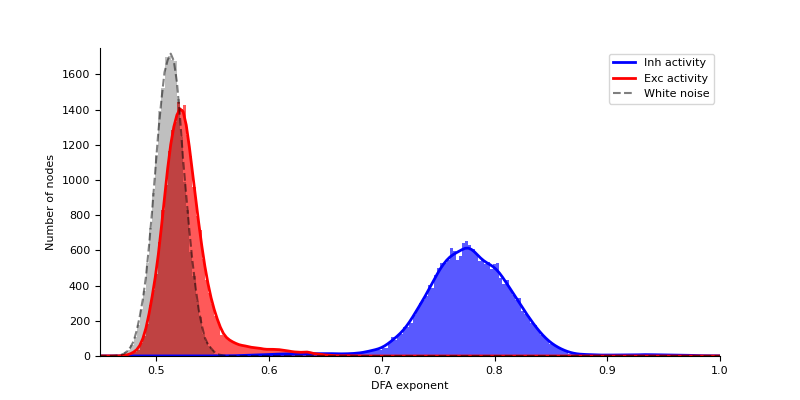

In [ ]:

band = "broadband"

edfa=np.load(f'/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/DFAexp_E_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_125sec_polyorder3_adaptaps.npy')
idfa=np.load(f'/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/DFAexp_I_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_125sec_polyorder3_adaptaps.npy')
ndfa=np.load(f'/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/DFAexp_whitenoise_{band}_125sec_polyorder3_adaptaps.npy')
#ndfa=np.load('/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/DFAexp_noise_envelope_125sec_polyorder3.npy')


plt.figure(figsize=(8,4))
hist = plt.hist(edfa,bins=400,range=(0.4,1.5),alpha=0.65,color='r')
hist1 = plt.hist(idfa,bins=400,range=(0.4,1.5),alpha=0.65,color='b')
 
hist2 = plt.hist(ndfa,bins=400,range=(0.4,1.5),alpha=0.25,color='k')



kde_responses = gaussian_kde(idfa)#,bw_method=hist1[1][20]-hist1[1][0])
bins_kde = hist1[1]
y=kde_responses(bins_kde)
plt.plot(bins_kde,y*hist1[0].mean()/y.mean(),c='b',lw=2,label='Inh activity')

kde_responses = gaussian_kde(edfa)#,bw_method=hist1[1][20]-hist1[1][0])
bins_kde = hist1[1]
y=kde_responses(bins_kde)
plt.plot(bins_kde,y*hist[0].mean()/y.mean(),c='r',lw=2,label='Exc activity')


kde_responses = gaussian_kde(ndfa)#,bw_method=hist1[1][20]-hist1[1][0])
bins_kde = hist2[1]#(hist2[1][1:])[hist2[0]>0]
y=kde_responses(bins_kde)
plt.plot(bins_kde,y*hist2[0].mean()/y.mean(),c='k',lw=1.5,ls='--',label='White noise',alpha=0.5)

plt.ylabel('Number of nodes')
plt.xlabel('DFA exponent')


#plt.plot(0.5*np.ones(100),np.linspace(0,hist2[0].max(),100),'k--')
plt.xlim(0.45,1)
plt.ylim(0,1750)
#plt.yscale('log')
plt.legend()
plt.savefig(f"/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/Figures/DFAexp_I_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_125sec_polyorder3_adaptaps.pdf", dpi=600, transparent=True) 

In [175]:
from scipy.stats import mannwhitneyu, ks_2samp
band = "broadband"

edfa=np.load(f'/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/DFAexp_E_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_125sec_polyorder3_adaptaps.npy')
idfa=np.load(f'/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/DFAexp_I_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_125sec_polyorder3_adaptaps.npy')
ndfa=np.load(f'/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/DFAexp_whitenoise_{band}_125sec_polyorder3_adaptaps.npy')

data_dist = edfa
null_dist = ndfa

# One-sided Mann-Whitney U test (data_dist > null_dist)
u_stat, p_value_two_sided = mannwhitneyu(data_dist, null_dist)
p_value_one_sided = p_value_two_sided

# KS test (two-sample)
ks_stat, ks_p_value = ks_2samp(data_dist, null_dist)

# Median difference relative to null's standard deviation
median_diff = np.median(data_dist) - np.median(null_dist)
null_std = np.std(null_dist, ddof=1)
effect_size = median_diff / null_std

#cohen
mean_diff = np.mean(data_dist) - np.mean(null_dist)
pooled_std = np.sqrt((np.std(data_dist, ddof=1)**2 + np.std(null_dist, ddof=1)**2) / 2)
cohen_d = mean_diff / pooled_std
print(f"Cohen's d: {cohen_d:.4f}")
print(f"KS statistic: {ks_stat:.4f}, KS p-value: {10*ks_p_value:.4e}")

# Results
print(f"One-sided p-value (Mann-Whitney U): {p_value_one_sided:.4e}")
print(f"Median difference / null std: {effect_size:.4f}")

Cohen's d: 1.9180
KS statistic: 0.7410, KS p-value: 0.0000e+00
One-sided p-value (Mann-Whitney U): 0.0000e+00
Median difference / null std: 2.5854


In [179]:
np.mean(idfa)

0.7833203061980724

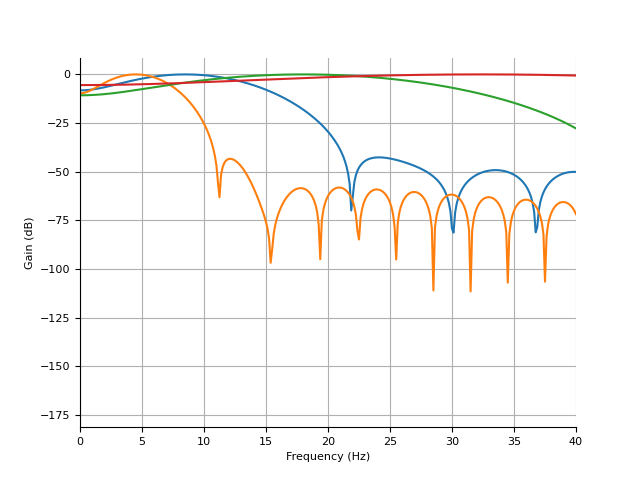

In [146]:
fs=500
plt.figure()
sos_alpha = sp.signal.firwin(int(167/2), (6,11), fs=fs, pass_zero='bandpass')
w, h = sp.signal.freqz(sos_alpha, worN=2000, fs=fs)


plt.plot(w, 20 * np.log10(abs(h)))
sos_theta = sp.signal.firwin(int(333/2), (3,6), fs=fs, pass_zero='bandpass')
w, h = sp.signal.freqz(sos_theta, worN=2000, fs=fs)
plt.plot(w, 20 * np.log10(abs(h)))
sos_beta = sp.signal.firwin(int(91/2), (11,25), fs=fs, pass_zero='bandpass')
w, h = sp.signal.freqz(sos_beta, worN=2000, fs=fs)
plt.plot(w, 20 * np.log10(abs(h)))
sos_gamma = sp.signal.firwin(int(41/2), (25,40), fs=fs, pass_zero='bandpass')
w, h = sp.signal.freqz(sos_gamma, worN=2000, fs=fs)
plt.plot(w, 20 * np.log10(abs(h)))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dB)')
plt.xlim(0,40)
plt.grid()
plt.show()


In [133]:
import mkl
mkl.set_num_threads(10)

import numpy as np
import scipy as sp 
from joblib import Parallel, delayed
sims_g_noise = np.random.default_rng().normal(0, 1, size=(400,300000))

min_window = 3
max_window = 25
polOrd = 3

winSizes = np.logspace(np.log10(min_window*fs),np.log10(max_window*fs),dtype='int',num=20)#fu.linRangeByStep(2*fs, 20*fs, step=100)
revSeg = True

def DFA_H(tseries):

    a = fu.toAggregated(tseries)

    pydfa = fathon.DFA(a)


    n, F = pydfa.computeFlucVec(winSizes, revSeg=revSeg, polOrd=polOrd)

    H, H_intercept  = pydfa.fitFlucVec(logBase=10)

    return H

filtered = sp.signal.lfilter(sos_alpha, 1, sims_g_noise)
env = np.abs(sp.signal.hilbert(filtered))

alpha_H = Parallel(n_jobs=10)(delayed(DFA_H)(env[vx]) for vx in range(env.shape[0]))

filtered = sp.signal.lfilter(sos_beta, 1, sims_g_noise)
env = np.abs(sp.signal.hilbert(filtered))

beta_H = Parallel(n_jobs=10)(delayed(DFA_H)(env[vx]) for vx in range(env.shape[0]))

filtered = sp.signal.lfilter(sos_theta, 1, sims_g_noise)
env = np.abs(sp.signal.hilbert(filtered))

theta_H = Parallel(n_jobs=10)(delayed(DFA_H)(env[vx]) for vx in range(env.shape[0]))



In [ ]:
# # Fourier-based bandpass filtering function
# def spectral_bandpass(signal, fs, freq_band):
#     N = len(signal)
#     freq = np.fft.fftfreq(N, d=1/fs)
#     fft_signal = np.fft.fft(signal)
#     mask = (np.abs(freq) >= freq_band[0]) & (np.abs(freq) <= freq_band[1])
#     fft_signal[~mask] = 0
#     return np.fft.ifft(fft_signal).real

# # Theta (3–6 Hz)
# filtered = np.array([spectral_bandpass(sims_g_noise[vx], fs=500, freq_band=(3, 6)) for vx in range(sims_g_noise.shape[0])])
# env = np.abs(sp.signal.hilbert(filtered))
# theta_H = Parallel(n_jobs=10)(delayed(DFA_H)(env[vx]) for vx in range(env.shape[0]))

# # Alpha (6–11 Hz)
# filtered = np.array([spectral_bandpass(sims_g_noise[vx], fs=500, freq_band=(6, 11)) for vx in range(sims_g_noise.shape[0])])
# env = np.abs(sp.signal.hilbert(filtered))
# alpha_H = Parallel(n_jobs=10)(delayed(DFA_H)(env[vx]) for vx in range(env.shape[0]))

# # Beta (11–25 Hz)
# filtered = np.array([spectral_bandpass(sims_g_noise[vx], fs=500, freq_band=(11, 25)) for vx in range(sims_g_noise.shape[0])])
# env = np.abs(sp.signal.hilbert(filtered))
# beta_H = Parallel(n_jobs=10)(delayed(DFA_H)(env[vx]) for vx in range(env.shape[0]))

In [116]:
env = np.abs(sp.signal.hilbert(sims_g_noise))

broadband_H = Parallel(n_jobs=10)(delayed(DFA_H)(env[vx]) for vx in range(env.shape[0]))


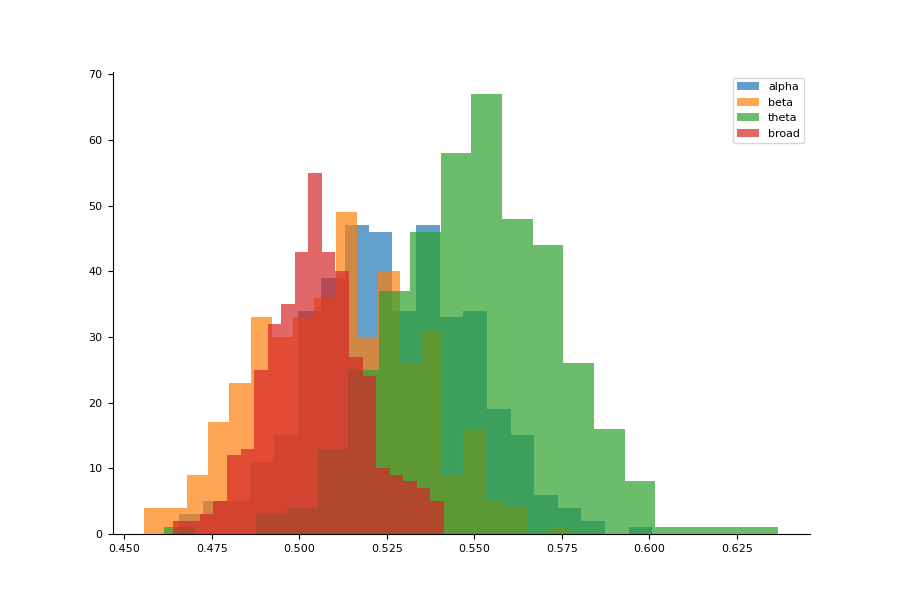

In [135]:
#325 poly3 poly3
plt.figure(figsize=(9,6))
plt.hist(alpha_H,bins=20,alpha=0.7, label='alpha')
plt.hist(beta_H,bins=20,alpha=0.7,label = 'beta')
plt.hist(theta_H,bins=20,alpha=0.7, label='theta')
plt.hist(broadband_H,bins=20,alpha=0.7, label='broad')
plt.legend()

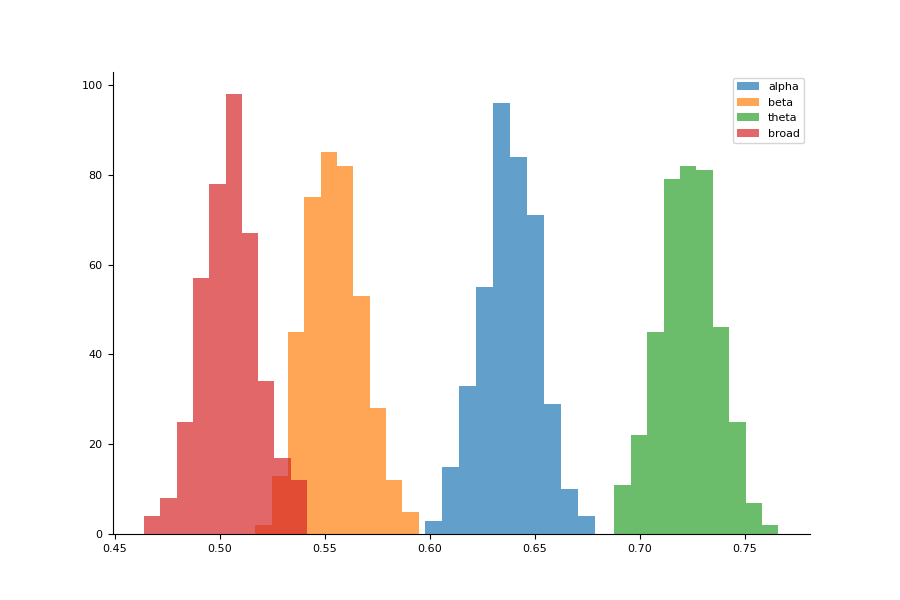

In [119]:
#125 poly3 fourier
plt.figure(figsize=(9,6))
plt.hist(alpha_H,bins=10,alpha=0.7, label='alpha')
plt.hist(beta_H,bins=10,alpha=0.7,label = 'beta')
plt.hist(theta_H,bins=10,alpha=0.7, label='theta')
plt.hist(broadband_H,bins=10,alpha=0.7, label='broad')
plt.legend()

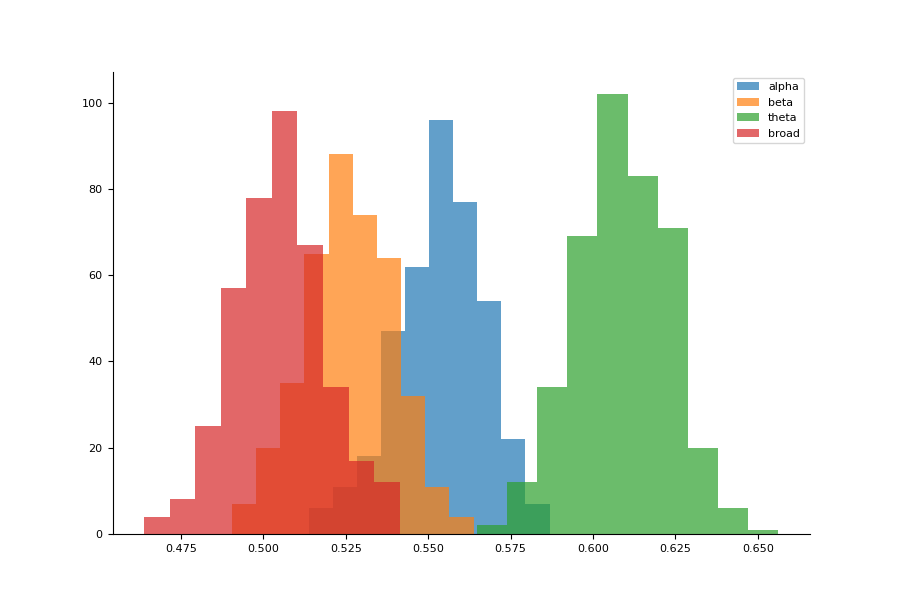

In [117]:
#125 poly3
plt.figure(figsize=(9,6))
plt.hist(alpha_H,bins=10,alpha=0.7, label='alpha')
plt.hist(beta_H,bins=10,alpha=0.7,label = 'beta')
plt.hist(theta_H,bins=10,alpha=0.7, label='theta')
plt.hist(broadband_H,bins=10,alpha=0.7, label='broad')
plt.legend()

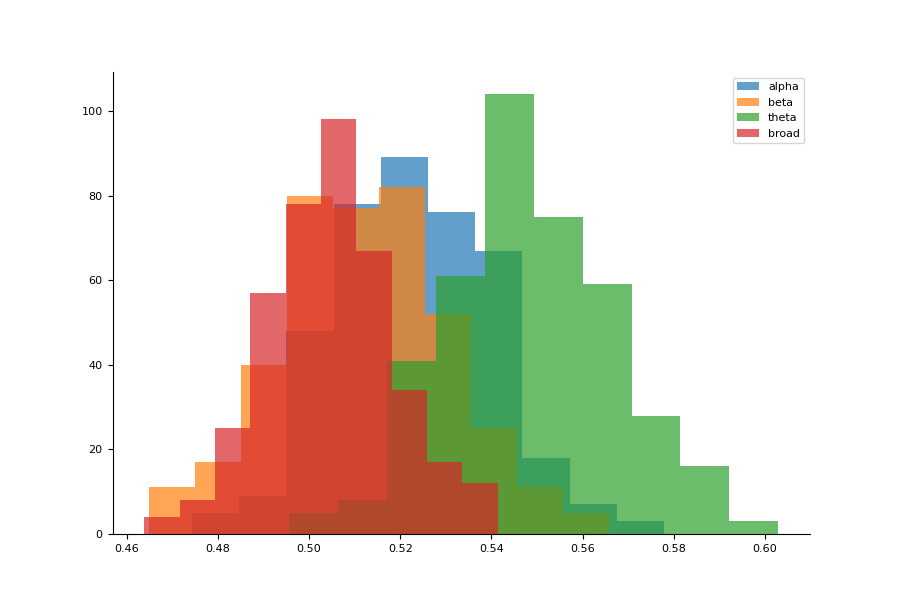

In [121]:
#125
plt.figure(figsize=(9,6))
plt.hist(alpha_H,bins=10,alpha=0.7, label='alpha')
plt.hist(beta_H,bins=10,alpha=0.7,label = 'beta')
plt.hist(theta_H,bins=10,alpha=0.7, label='theta')
plt.hist(broadband_H,bins=10,alpha=0.7, label='broad')
plt.legend()

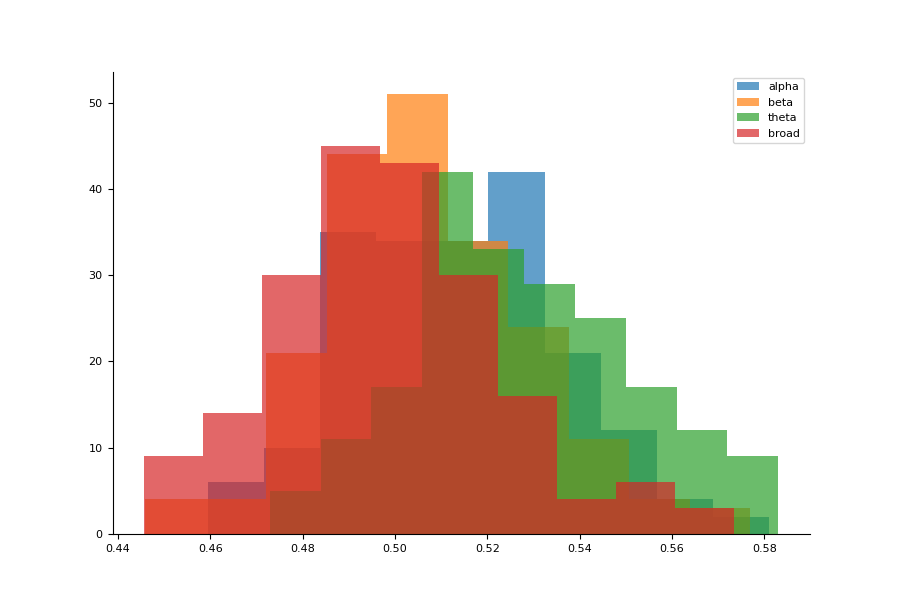

In [ ]:
#225
plt.figure(figsize=(9,6))
plt.hist(alpha_H,bins=10,alpha=0.7, label='alpha')
plt.hist(beta_H,bins=10,alpha=0.7,label = 'beta')
plt.hist(theta_H,bins=10,alpha=0.7, label='theta')
plt.hist(broadband_H,bins=10,alpha=0.7, label='broad')
plt.legend()

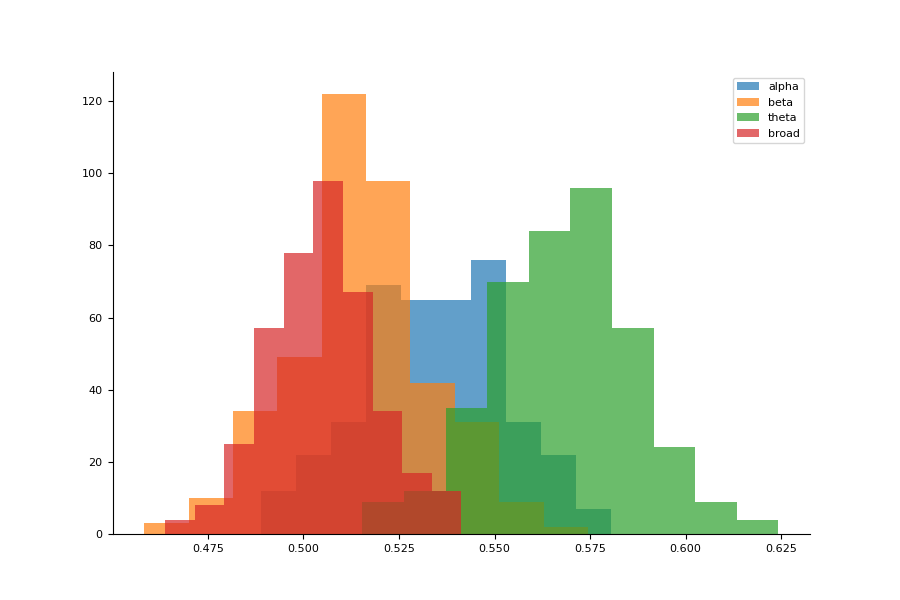

In [124]:
#225 poly3
plt.figure(figsize=(9,6))
plt.hist(alpha_H,bins=10,alpha=0.7, label='alpha')
plt.hist(beta_H,bins=10,alpha=0.7,label = 'beta')
plt.hist(theta_H,bins=10,alpha=0.7, label='theta')
plt.hist(broadband_H,bins=10,alpha=0.7, label='broad')
plt.legend()

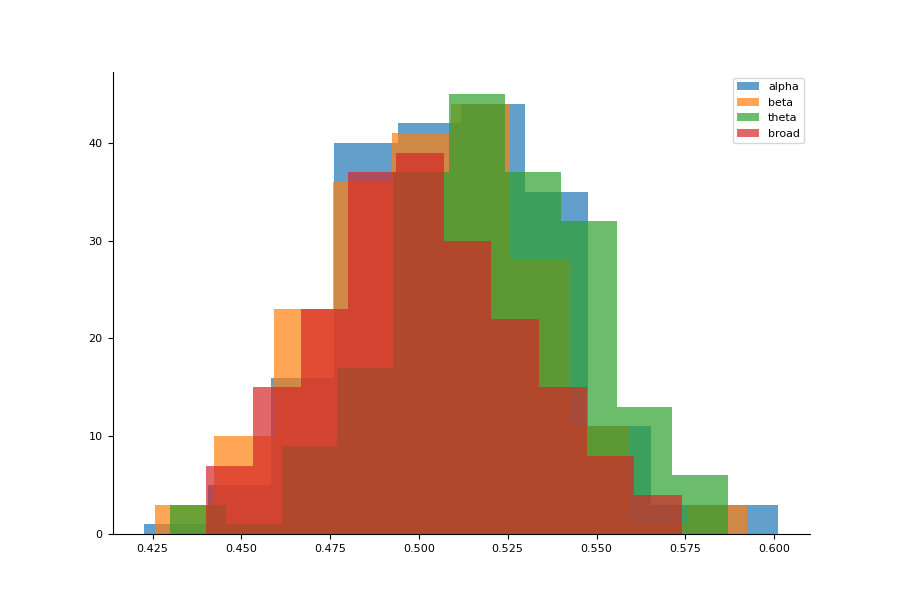

In [ ]:
#330
plt.figure(figsize=(9,6))
plt.hist(alpha_H,bins=10,alpha=0.7, label='alpha')
plt.hist(beta_H,bins=10,alpha=0.7,label = 'beta')
plt.hist(theta_H,bins=10,alpha=0.7, label='theta')
plt.hist(broadband_H,bins=10,alpha=0.7, label='broad')
plt.legend()

In [3]:
paths_i = natsorted(glob.glob('/data1/projects/dumoulinlab/Lab_members/Marco/10min_beta_sim_20khz/beta_I_activity*.npy'))

In [4]:
paths_e = natsorted(glob.glob('/data1/projects/dumoulinlab/Lab_members/Marco/10min_beta_sim_20khz/beta_E_activity*.npy'))

In [35]:
#go to millisecond scale
#WARNING downsampling with proper methods like scipy decimate actually changes the SPS
#dumb downsampling somehow doesnt
dsample = 20

for p_e in [p for p in paths_e if 'downsampled' not in p]:
    
    if not os.path.exists(p_e.replace('activity','activity_downsampled')):
    
        tt = np.load(p_e)

        dsampled_tt = tt[:,::dsample]#sp.signal.decimate(tt, dsample)

        np.save(p_e.replace('activity','activity_downsampled'), dsampled_tt)

        os.remove(p_e)

for p_i in [p for p in paths_i if 'downsampled' not in p]:
    
    if not os.path.exists(p_i.replace('activity','activity_downsampled')):
    
        tt = np.load(p_i)

        dsampled_tt = tt[:,::dsample]#sp.signal.decimate(tt, dsample)

        np.save(p_i.replace('activity','activity_downsampled'), dsampled_tt)

        os.remove(p_i)



In [ ]:
import mkl
mkl.set_num_threads(10)

import numpy as np
import scipy as sp 
import os
import glob
import fathon
from natsort import natsorted
from fathon import fathonUtils as fu
import time


d_path = '/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/10min_beta_sim_20khz/'

paths_e = natsorted(glob.glob(f'{d_path}/beta_E_activity*.npy'))
paths_i = natsorted(glob.glob(f'{d_path}/beta_I_activity*.npy'))


for p_e in [p for p in paths_e if 'downsampled' not in p]:
    
    if not os.path.exists(p_e.replace('activity','activity_downsampled')):
    
        tt = np.load(p_e)

        dsampled_tt = sp.signal.decimate(tt, dsample)

        np.save(p_e.replace('activity','activity_downsampled'), dsampled_tt)

        os.remove(p_e)

for p_i in [p for p in paths_i if 'downsampled' not in p]:
    
    if not os.path.exists(p_i.replace('activity','activity_downsampled')):
    
        tt = np.load(p_i)

        dsampled_tt = sp.signal.decimate(tt, dsample)

        np.save(p_i.replace('activity','activity_downsampled'), dsampled_tt)

        os.remove(p_i)
        
    

In [7]:
paths_e = natsorted(glob.glob('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/12min_beta_sim_20khz/beta_E_activity*.npy'))
#from 20k to 1k hertz to avoid storing too much data
dsample_1 = 20
nsim = 120
#to 250hz for faster calculations
dsample_2 = 4

sims = np.concatenate([np.load(p)[:,::dsample_2] for p in paths_e[:nsim]],axis=-1)

fs=20000//(dsample_1*dsample_2)

eigenvectors = np.load('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/eigvecs_DTI_fgCCfix_subcortex_dti50.npy')

sims_g = np.dot(eigenvectors,sims)

del sims

sos_alpha = sp.signal.firwin(3, (8,13), fs=fs, pass_zero='bandpass')

#sos_beta = sp.signal.firwin(3, (13,30), fs=fs, pass_zero='bandpass')

filtered = sp.signal.lfilter(sos_alpha, 1, sims_g)

del sims_g

env = np.abs(sp.signal.hilbert(filtered))

del filtered

In [8]:
np.save('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/E_alpha_envelope.npy',env)

In [8]:
env = np.load('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/E_alpha_envelope.npy')

In [9]:
min_window = 2
max_window = 20

#from 20k to 1k hertz to avoid storing too much data
dsample_1 = 20
nsim = 120
#to 250hz for faster calculations
dsample_2 = 4
fs=20000//(dsample_1*dsample_2)

all_n = []
all_F = []
all_H = []
all_H_intercept = []


for vx in range(env.shape[0]):
    print(vx)
    a = fu.toAggregated(env[vx])

    pydfa = fathon.DFA(a)
    winSizes = np.logspace(np.log10(min_window*fs),np.log10(max_window*fs),dtype='int',num=20)#fu.linRangeByStep(2*fs, 20*fs, step=100)
    revSeg = False
    
    polOrd = 3

    n, F = pydfa.computeFlucVec(winSizes, revSeg=revSeg, polOrd=polOrd)
    all_n.append(n)
    all_F.append(F)

    H, H_intercept = pydfa.fitFlucVec(logBase=10)
    all_H.append(H)
    all_H_intercept.append(H_intercept)
    print(f'{H:.3f}')
    print(f'frac vertices above 0.6: {(np.sum(np.array(all_H)>0.6)/len(all_H)):.2f}')

0
0.511
frac vertices above 0.6: 0.00
1
0.473
frac vertices above 0.6: 0.00
2
0.523
frac vertices above 0.6: 0.00
3
0.500
frac vertices above 0.6: 0.00
4
0.513
frac vertices above 0.6: 0.00
5
0.547
frac vertices above 0.6: 0.00
6
0.827
frac vertices above 0.6: 0.14
7
0.562
frac vertices above 0.6: 0.12
8
0.507
frac vertices above 0.6: 0.11
9
0.506
frac vertices above 0.6: 0.10
10
0.537
frac vertices above 0.6: 0.09
11
0.550
frac vertices above 0.6: 0.08
12
0.487
frac vertices above 0.6: 0.08
13
0.525
frac vertices above 0.6: 0.07
14
0.555
frac vertices above 0.6: 0.07
15
0.522
frac vertices above 0.6: 0.06
16
0.539
frac vertices above 0.6: 0.06
17
0.518
frac vertices above 0.6: 0.06
18
0.673
frac vertices above 0.6: 0.11
19
0.498
frac vertices above 0.6: 0.10
20
1.166
frac vertices above 0.6: 0.14
21
0.495
frac vertices above 0.6: 0.14
22
0.522
frac vertices above 0.6: 0.13
23
0.846
frac vertices above 0.6: 0.17
24
0.480
frac vertices above 0.6: 0.16
25
0.534
frac vertices above 0.6: 0

0.526
frac vertices above 0.6: 0.15
209
0.622
frac vertices above 0.6: 0.16
210
0.511
frac vertices above 0.6: 0.16
211
1.133
frac vertices above 0.6: 0.16
212
0.483
frac vertices above 0.6: 0.16
213
0.506
frac vertices above 0.6: 0.16
214
0.515
frac vertices above 0.6: 0.16
215
0.523
frac vertices above 0.6: 0.16
216
0.516
frac vertices above 0.6: 0.16
217
0.505
frac vertices above 0.6: 0.16
218
0.502
frac vertices above 0.6: 0.16
219
0.514
frac vertices above 0.6: 0.15
220
0.898
frac vertices above 0.6: 0.16
221
0.666
frac vertices above 0.6: 0.16
222
0.512
frac vertices above 0.6: 0.16
223
0.513
frac vertices above 0.6: 0.16
224
0.527
frac vertices above 0.6: 0.16
225
0.501
frac vertices above 0.6: 0.16
226
0.544
frac vertices above 0.6: 0.16
227
0.536
frac vertices above 0.6: 0.16
228
0.514
frac vertices above 0.6: 0.16
229
0.490
frac vertices above 0.6: 0.16
230
0.507
frac vertices above 0.6: 0.16
231
0.493
frac vertices above 0.6: 0.16
232
0.500
frac vertices above 0.6: 0.15
233


0.523
frac vertices above 0.6: 0.16
414
0.515
frac vertices above 0.6: 0.16
415
0.507
frac vertices above 0.6: 0.16
416
0.512
frac vertices above 0.6: 0.16
417
0.506
frac vertices above 0.6: 0.16
418
0.539
frac vertices above 0.6: 0.16
419
0.500
frac vertices above 0.6: 0.15
420
0.520
frac vertices above 0.6: 0.15
421
0.515
frac vertices above 0.6: 0.15
422
0.964
frac vertices above 0.6: 0.16
423
0.809
frac vertices above 0.6: 0.16
424
0.517
frac vertices above 0.6: 0.16
425
0.507
frac vertices above 0.6: 0.16
426
0.544
frac vertices above 0.6: 0.16
427
0.500
frac vertices above 0.6: 0.16
428
0.528
frac vertices above 0.6: 0.16
429
0.513
frac vertices above 0.6: 0.16
430
0.519
frac vertices above 0.6: 0.16
431
0.542
frac vertices above 0.6: 0.16
432
0.509
frac vertices above 0.6: 0.15
433
0.534
frac vertices above 0.6: 0.15
434
0.498
frac vertices above 0.6: 0.15
435
0.524
frac vertices above 0.6: 0.15
436
0.531
frac vertices above 0.6: 0.15
437
0.526
frac vertices above 0.6: 0.15
438


0.572
frac vertices above 0.6: 0.17
619
0.500
frac vertices above 0.6: 0.17
620
0.712
frac vertices above 0.6: 0.17
621
0.536
frac vertices above 0.6: 0.17
622
0.509
frac vertices above 0.6: 0.17
623
0.511
frac vertices above 0.6: 0.17
624
0.533
frac vertices above 0.6: 0.17
625
0.512
frac vertices above 0.6: 0.17
626
0.532
frac vertices above 0.6: 0.17
627
0.526
frac vertices above 0.6: 0.17
628
0.490
frac vertices above 0.6: 0.17
629
0.536
frac vertices above 0.6: 0.17
630
0.518
frac vertices above 0.6: 0.16
631
0.510
frac vertices above 0.6: 0.16
632
0.496
frac vertices above 0.6: 0.16
633
0.519
frac vertices above 0.6: 0.16
634
0.498
frac vertices above 0.6: 0.16
635
0.510
frac vertices above 0.6: 0.16
636
0.473
frac vertices above 0.6: 0.16
637
0.519
frac vertices above 0.6: 0.16
638
0.506
frac vertices above 0.6: 0.16
639
0.512
frac vertices above 0.6: 0.16
640
0.514
frac vertices above 0.6: 0.16
641
0.531
frac vertices above 0.6: 0.16
642
0.506
frac vertices above 0.6: 0.16
643


0.506
frac vertices above 0.6: 0.16
824
0.530
frac vertices above 0.6: 0.16
825
0.512
frac vertices above 0.6: 0.16
826
0.523
frac vertices above 0.6: 0.16
827
0.991
frac vertices above 0.6: 0.16
828
0.533
frac vertices above 0.6: 0.16
829
0.522
frac vertices above 0.6: 0.16
830
0.492
frac vertices above 0.6: 0.16
831
0.503
frac vertices above 0.6: 0.16
832
0.519
frac vertices above 0.6: 0.16
833
0.527
frac vertices above 0.6: 0.16
834
0.489
frac vertices above 0.6: 0.16
835
0.510
frac vertices above 0.6: 0.16
836
0.551
frac vertices above 0.6: 0.16
837
0.507
frac vertices above 0.6: 0.16
838
0.510
frac vertices above 0.6: 0.16
839
0.529
frac vertices above 0.6: 0.16
840
0.520
frac vertices above 0.6: 0.16
841
0.478
frac vertices above 0.6: 0.16
842
0.511
frac vertices above 0.6: 0.16
843
0.459
frac vertices above 0.6: 0.16
844
0.538
frac vertices above 0.6: 0.16
845
0.649
frac vertices above 0.6: 0.16
846
0.561
frac vertices above 0.6: 0.16
847
0.584
frac vertices above 0.6: 0.16
848


...

0.524
frac vertices above 0.6: 0.17
19633
0.620
frac vertices above 0.6: 0.17
19634
0.691
frac vertices above 0.6: 0.17
19635
0.514
frac vertices above 0.6: 0.17
19636
0.555
frac vertices above 0.6: 0.17
19637
0.559
frac vertices above 0.6: 0.17
19638
0.942
frac vertices above 0.6: 0.17
19639
1.145
frac vertices above 0.6: 0.17
19640
0.736
frac vertices above 0.6: 0.17
19641
0.499
frac vertices above 0.6: 0.17
19642
0.626
frac vertices above 0.6: 0.17
19643
0.525
frac vertices above 0.6: 0.17
19644
0.498
frac vertices above 0.6: 0.17
19645
0.536
frac vertices above 0.6: 0.17
19646
0.533
frac vertices above 0.6: 0.17
19647
0.529
frac vertices above 0.6: 0.17
19648
1.342
frac vertices above 0.6: 0.17
19649
0.591
frac vertices above 0.6: 0.17
19650
0.518
frac vertices above 0.6: 0.17
19651
0.515
frac vertices above 0.6: 0.17
19652
0.688
frac vertices above 0.6: 0.17
19653
0.549
frac vertices above 0.6: 0.17
19654
0.505
frac vertices above 0.6: 0.17
19655
0.650
frac vertices above 0.6: 0.1

0.490
frac vertices above 0.6: 0.17
19829
0.529
frac vertices above 0.6: 0.17
19830
0.515
frac vertices above 0.6: 0.17
19831
0.546
frac vertices above 0.6: 0.17
19832
0.509
frac vertices above 0.6: 0.17
19833
0.517
frac vertices above 0.6: 0.17
19834
0.524
frac vertices above 0.6: 0.17
19835
0.627
frac vertices above 0.6: 0.17
19836
0.730
frac vertices above 0.6: 0.17
19837
0.670
frac vertices above 0.6: 0.17
19838
0.726
frac vertices above 0.6: 0.17
19839
0.823
frac vertices above 0.6: 0.17
19840
0.542
frac vertices above 0.6: 0.17
19841
0.696
frac vertices above 0.6: 0.17
19842
0.495
frac vertices above 0.6: 0.17
19843
0.482
frac vertices above 0.6: 0.17
19844
0.517
frac vertices above 0.6: 0.17
19845
0.517
frac vertices above 0.6: 0.17
19846
0.544
frac vertices above 0.6: 0.17
19847
0.581
frac vertices above 0.6: 0.17
19848
0.507
frac vertices above 0.6: 0.17
19849
0.512
frac vertices above 0.6: 0.17
19850
0.556
frac vertices above 0.6: 0.17
19851
0.521
frac vertices above 0.6: 0.1

0.496
frac vertices above 0.6: 0.17
20025
0.475
frac vertices above 0.6: 0.17
20026
0.664
frac vertices above 0.6: 0.17
20027
0.580
frac vertices above 0.6: 0.17
20028
0.524
frac vertices above 0.6: 0.17
20029
0.505
frac vertices above 0.6: 0.17
20030
0.594
frac vertices above 0.6: 0.17
20031
0.555
frac vertices above 0.6: 0.17
20032
0.559
frac vertices above 0.6: 0.17
20033
0.536
frac vertices above 0.6: 0.17
20034
0.517
frac vertices above 0.6: 0.17
20035
0.568
frac vertices above 0.6: 0.17
20036
0.548
frac vertices above 0.6: 0.17
20037
0.841
frac vertices above 0.6: 0.17
20038
0.687
frac vertices above 0.6: 0.17
20039
0.656
frac vertices above 0.6: 0.17
20040
0.987
frac vertices above 0.6: 0.17
20041
0.574
frac vertices above 0.6: 0.17
20042
0.523
frac vertices above 0.6: 0.17
20043
0.514
frac vertices above 0.6: 0.17
20044
1.026
frac vertices above 0.6: 0.17
20045
0.677
frac vertices above 0.6: 0.17
20046
0.524
frac vertices above 0.6: 0.17
20047
0.531
frac vertices above 0.6: 0.1

0.514
frac vertices above 0.6: 0.17
20221
0.515
frac vertices above 0.6: 0.17
20222
0.538
frac vertices above 0.6: 0.17
20223
0.511
frac vertices above 0.6: 0.17
20224
1.282
frac vertices above 0.6: 0.17
20225
0.556
frac vertices above 0.6: 0.17
20226
0.486
frac vertices above 0.6: 0.17
20227
0.508
frac vertices above 0.6: 0.17
20228
0.960
frac vertices above 0.6: 0.17
20229
0.531
frac vertices above 0.6: 0.17
20230
0.492
frac vertices above 0.6: 0.17
20231
0.537
frac vertices above 0.6: 0.17
20232
0.526
frac vertices above 0.6: 0.17
20233
0.514
frac vertices above 0.6: 0.17
20234
0.534
frac vertices above 0.6: 0.17
20235
0.494
frac vertices above 0.6: 0.17
20236
0.533
frac vertices above 0.6: 0.17
20237
0.650
frac vertices above 0.6: 0.17
20238
0.966
frac vertices above 0.6: 0.17
20239
0.461
frac vertices above 0.6: 0.17
20240
0.501
frac vertices above 0.6: 0.17
20241
0.798
frac vertices above 0.6: 0.17
20242
0.538
frac vertices above 0.6: 0.17
20243
0.521
frac vertices above 0.6: 0.1

1.157
frac vertices above 0.6: 0.17
20417
0.539
frac vertices above 0.6: 0.17
20418
0.529
frac vertices above 0.6: 0.17
20419
0.517
frac vertices above 0.6: 0.17
20420
0.516
frac vertices above 0.6: 0.17
20421
0.530
frac vertices above 0.6: 0.17
20422
0.519
frac vertices above 0.6: 0.17
20423
0.509
frac vertices above 0.6: 0.17
20424
0.512
frac vertices above 0.6: 0.17
20425
0.493
frac vertices above 0.6: 0.17
20426
0.483
frac vertices above 0.6: 0.17
20427
0.499
frac vertices above 0.6: 0.17
20428
0.504
frac vertices above 0.6: 0.17
20429
0.500
frac vertices above 0.6: 0.17
20430
0.484
frac vertices above 0.6: 0.17
20431
0.544
frac vertices above 0.6: 0.17
20432
0.519
frac vertices above 0.6: 0.17
20433
0.511
frac vertices above 0.6: 0.17
20434
0.499
frac vertices above 0.6: 0.17
20435
0.535
frac vertices above 0.6: 0.17
20436
0.516
frac vertices above 0.6: 0.17
20437
0.542
frac vertices above 0.6: 0.17
20438
0.543
frac vertices above 0.6: 0.17
20439
1.050
frac vertices above 0.6: 0.1

In [10]:
np.save('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/DFAexp_E_813alpha_220sec_polyorder3.npy',all_H)

In [13]:
#from 20k to 1k hertz to avoid storing too much data
dsample_1 = 20
nsim = 120
#to 250hz for faster calculations
dsample_2 = 4

sims = np.concatenate([np.load(p)[:,::dsample_2] for p in paths_i[:nsim]],axis=-1)

fs=20000//(dsample_1*dsample_2)

eigenvectors = np.load('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/eigvecs_DTI_fgCCfix_subcortex_dti50.npy')

sims_g = np.dot(eigenvectors,sims)

del sims



sos_alpha = sp.signal.firwin(3, (8,13), fs=fs, pass_zero='bandpass')

#sos_beta = sp.signal.firwin(3, (13,30), fs=fs, pass_zero='bandpass')

filtered = sp.signal.lfilter(sos_alpha, 1, sims_g)

del sims_g

env = np.abs(sp.signal.hilbert(filtered))

del filtered

In [ ]:
np.save('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/I_alpha_envelope.npy',env)

In [ ]:
env = np.load('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/I_alpha_envelope.npy')

min_window = 2
max_window = 20

#from 20k to 1k hertz to avoid storing too much data
dsample_1 = 20
nsim = 120
#to 250hz for faster calculations
dsample_2 = 4
fs=20000//(dsample_1*dsample_2)

all_n = []
all_F = []
all_H = []
all_H_intercept = []


for vx in range(env.shape[0]):
    print(vx)
    a = fu.toAggregated(env[vx])

    pydfa = fathon.DFA(a)
    winSizes = np.logspace(np.log10(min_window*fs),np.log10(max_window*fs),dtype='int',num=20)#fu.linRangeByStep(2*fs, 20*fs, step=100)
    revSeg = False
    
    polOrd = 3

    n, F = pydfa.computeFlucVec(winSizes, revSeg=revSeg, polOrd=polOrd)
    all_n.append(n)
    all_F.append(F)

    H, H_intercept = pydfa.fitFlucVec(logBase=10)
    all_H.append(H)
    all_H_intercept.append(H_intercept)
    print(f'{H:.3f}')
    print(f'frac vertices above 0.6: {(np.sum(np.array(all_H)>0.6)/len(all_H)):.2f}')
    
np.save('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/DFAexp_I_813alpha_220sec_polyorder3.npy',all_H)    

0
0.742
frac vertices above 0.6: 1.00
1
0.580
frac vertices above 0.6: 0.50
2
0.632
frac vertices above 0.6: 0.67
3
0.596
frac vertices above 0.6: 0.50
4
0.586
frac vertices above 0.6: 0.40
5
0.615
frac vertices above 0.6: 0.50
6
0.854
frac vertices above 0.6: 0.57
7
0.919
frac vertices above 0.6: 0.62
8
0.601
frac vertices above 0.6: 0.67
9
0.669
frac vertices above 0.6: 0.70
10
0.633
frac vertices above 0.6: 0.73
11
0.628
frac vertices above 0.6: 0.75
12
0.561
frac vertices above 0.6: 0.69
13
0.628
frac vertices above 0.6: 0.71
14
0.595
frac vertices above 0.6: 0.67
15
0.574
frac vertices above 0.6: 0.62
16
0.596
frac vertices above 0.6: 0.59
17
0.578
frac vertices above 0.6: 0.56
18
0.771
frac vertices above 0.6: 0.58
19
0.582
frac vertices above 0.6: 0.55
20
1.168
frac vertices above 0.6: 0.57
21
0.558
frac vertices above 0.6: 0.55
22
0.608
frac vertices above 0.6: 0.57
23
0.926
frac vertices above 0.6: 0.58
24
0.572
frac vertices above 0.6: 0.56
25
0.562
frac vertices above 0.6: 0

0.595
frac vertices above 0.6: 0.54
209
0.886
frac vertices above 0.6: 0.54
210
0.630
frac vertices above 0.6: 0.54
211
1.337
frac vertices above 0.6: 0.54
212
0.592
frac vertices above 0.6: 0.54
213
0.569
frac vertices above 0.6: 0.54
214
0.569
frac vertices above 0.6: 0.53
215
0.543
frac vertices above 0.6: 0.53
216
0.585
frac vertices above 0.6: 0.53
217
0.555
frac vertices above 0.6: 0.53
218
0.652
frac vertices above 0.6: 0.53
219
0.570
frac vertices above 0.6: 0.53
220
0.947
frac vertices above 0.6: 0.53
221
0.816
frac vertices above 0.6: 0.53
222
0.579
frac vertices above 0.6: 0.53
223
0.616
frac vertices above 0.6: 0.53
224
0.545
frac vertices above 0.6: 0.53
225
0.676
frac vertices above 0.6: 0.53
226
0.704
frac vertices above 0.6: 0.53
227
0.627
frac vertices above 0.6: 0.54
228
0.623
frac vertices above 0.6: 0.54
229
0.664
frac vertices above 0.6: 0.54
230
0.595
frac vertices above 0.6: 0.54
231
0.547
frac vertices above 0.6: 0.53
232
0.606
frac vertices above 0.6: 0.54
233


0.617
frac vertices above 0.6: 0.55
414
0.580
frac vertices above 0.6: 0.54
415
0.599
frac vertices above 0.6: 0.54
416
0.614
frac vertices above 0.6: 0.54
417
0.587
frac vertices above 0.6: 0.54
418
0.631
frac vertices above 0.6: 0.54
419
0.629
frac vertices above 0.6: 0.55
420
0.615
frac vertices above 0.6: 0.55
421
0.608
frac vertices above 0.6: 0.55
422
1.114
frac vertices above 0.6: 0.55
423
0.894
frac vertices above 0.6: 0.55
424
0.603
frac vertices above 0.6: 0.55
425
0.599
frac vertices above 0.6: 0.55
426
0.575
frac vertices above 0.6: 0.55
427
0.578
frac vertices above 0.6: 0.55
428
0.626
frac vertices above 0.6: 0.55
429
0.567
frac vertices above 0.6: 0.55
430
0.585
frac vertices above 0.6: 0.55
431
0.596
frac vertices above 0.6: 0.54
432
0.633
frac vertices above 0.6: 0.55
433
0.582
frac vertices above 0.6: 0.54
434
0.606
frac vertices above 0.6: 0.54
435
0.621
frac vertices above 0.6: 0.55
436
0.628
frac vertices above 0.6: 0.55
437
0.599
frac vertices above 0.6: 0.55
438


0.644
frac vertices above 0.6: 0.57
619
0.564
frac vertices above 0.6: 0.56
620
0.862
frac vertices above 0.6: 0.57
621
0.667
frac vertices above 0.6: 0.57
622
0.750
frac vertices above 0.6: 0.57
623
0.637
frac vertices above 0.6: 0.57
624
0.588
frac vertices above 0.6: 0.57
625
0.588
frac vertices above 0.6: 0.57
626
0.588
frac vertices above 0.6: 0.56
627
0.603
frac vertices above 0.6: 0.57
628
0.604
frac vertices above 0.6: 0.57
629
0.572
frac vertices above 0.6: 0.57
630
0.578
frac vertices above 0.6: 0.56
631
0.653
frac vertices above 0.6: 0.56
632
0.583
frac vertices above 0.6: 0.56
633
0.645
frac vertices above 0.6: 0.56
634
0.601
frac vertices above 0.6: 0.57
635
0.635
frac vertices above 0.6: 0.57
636
0.602
frac vertices above 0.6: 0.57
637
0.597
frac vertices above 0.6: 0.57
638
0.596
frac vertices above 0.6: 0.56
639
0.624
frac vertices above 0.6: 0.57
640
0.562
frac vertices above 0.6: 0.56
641
0.589
frac vertices above 0.6: 0.56
642
0.555
frac vertices above 0.6: 0.56
643


0.577
frac vertices above 0.6: 0.56
824
0.592
frac vertices above 0.6: 0.56
825
0.571
frac vertices above 0.6: 0.56
826
0.602
frac vertices above 0.6: 0.56
827
0.990
frac vertices above 0.6: 0.56
828
0.605
frac vertices above 0.6: 0.56
829
0.584
frac vertices above 0.6: 0.56
830
0.598
frac vertices above 0.6: 0.56
831
0.549
frac vertices above 0.6: 0.56
832
0.599
frac vertices above 0.6: 0.56
833
0.586
frac vertices above 0.6: 0.56
834
0.562
frac vertices above 0.6: 0.56
835
0.595
frac vertices above 0.6: 0.56
836
0.589
frac vertices above 0.6: 0.56
837
0.590
frac vertices above 0.6: 0.56
838
0.592
frac vertices above 0.6: 0.56
839
0.573
frac vertices above 0.6: 0.56
840
0.630
frac vertices above 0.6: 0.56
841
0.588
frac vertices above 0.6: 0.56
842
0.568
frac vertices above 0.6: 0.56
843
0.605
frac vertices above 0.6: 0.56
844
0.622
frac vertices above 0.6: 0.56
845
1.007
frac vertices above 0.6: 0.56
846
0.711
frac vertices above 0.6: 0.56
847
0.979
frac vertices above 0.6: 0.56
848


...

0.803
frac vertices above 0.6: 0.58
10029
1.050
frac vertices above 0.6: 0.58
10030
0.757
frac vertices above 0.6: 0.58
10031
0.587
frac vertices above 0.6: 0.58
10032
0.608
frac vertices above 0.6: 0.58
10033
0.578
frac vertices above 0.6: 0.58
10034
0.609
frac vertices above 0.6: 0.58
10035
0.600
frac vertices above 0.6: 0.58
10036
0.587
frac vertices above 0.6: 0.58
10037
0.565
frac vertices above 0.6: 0.58
10038
0.558
frac vertices above 0.6: 0.58
10039
0.542
frac vertices above 0.6: 0.58
10040
0.586
frac vertices above 0.6: 0.58
10041
0.535
frac vertices above 0.6: 0.58
10042
0.555
frac vertices above 0.6: 0.58
10043
0.576
frac vertices above 0.6: 0.58
10044
0.825
frac vertices above 0.6: 0.58
10045
0.992
frac vertices above 0.6: 0.58
10046
1.054
frac vertices above 0.6: 0.58
10047
0.806
frac vertices above 0.6: 0.58
10048
1.137
frac vertices above 0.6: 0.58
10049
0.663
frac vertices above 0.6: 0.58
10050
0.800
frac vertices above 0.6: 0.58
10051
0.578
frac vertices above 0.6: 0.5

0.558
frac vertices above 0.6: 0.58
10225
0.644
frac vertices above 0.6: 0.58
10226
0.861
frac vertices above 0.6: 0.58
10227
0.566
frac vertices above 0.6: 0.58
10228
0.722
frac vertices above 0.6: 0.58
10229
0.957
frac vertices above 0.6: 0.58
10230
1.163
frac vertices above 0.6: 0.58
10231
1.017
frac vertices above 0.6: 0.58
10232
1.040
frac vertices above 0.6: 0.58
10233
0.586
frac vertices above 0.6: 0.58
10234
0.605
frac vertices above 0.6: 0.58
10235
0.932
frac vertices above 0.6: 0.58
10236
0.570
frac vertices above 0.6: 0.58
10237
0.920
frac vertices above 0.6: 0.58
10238
0.714
frac vertices above 0.6: 0.58
10239
0.563
frac vertices above 0.6: 0.58
10240
0.616
frac vertices above 0.6: 0.58
10241
0.757
frac vertices above 0.6: 0.58
10242
0.655
frac vertices above 0.6: 0.58
10243
0.607
frac vertices above 0.6: 0.58
10244
0.583
frac vertices above 0.6: 0.58
10245
0.587
frac vertices above 0.6: 0.58
10246
0.731
frac vertices above 0.6: 0.58
10247
0.934
frac vertices above 0.6: 0.5

0.614
frac vertices above 0.6: 0.58
10421
0.566
frac vertices above 0.6: 0.58
10422
0.587
frac vertices above 0.6: 0.58
10423
0.572
frac vertices above 0.6: 0.58
10424
0.638
frac vertices above 0.6: 0.58
10425
0.576
frac vertices above 0.6: 0.58
10426
0.674
frac vertices above 0.6: 0.58
10427
0.717
frac vertices above 0.6: 0.58
10428
1.291
frac vertices above 0.6: 0.58
10429
1.177
frac vertices above 0.6: 0.58
10430
0.630
frac vertices above 0.6: 0.58
10431
0.863
frac vertices above 0.6: 0.58
10432
0.585
frac vertices above 0.6: 0.58
10433
1.253
frac vertices above 0.6: 0.58
10434
1.099
frac vertices above 0.6: 0.58
10435
1.345
frac vertices above 0.6: 0.58
10436
0.603
frac vertices above 0.6: 0.58
10437
0.622
frac vertices above 0.6: 0.58
10438
0.641
frac vertices above 0.6: 0.58
10439
0.594
frac vertices above 0.6: 0.58
10440
0.639
frac vertices above 0.6: 0.58
10441
0.612
frac vertices above 0.6: 0.58
10442
0.586
frac vertices above 0.6: 0.58
10443
0.615
frac vertices above 0.6: 0.5

0.598
frac vertices above 0.6: 0.58
10617
0.596
frac vertices above 0.6: 0.58
10618
0.880
frac vertices above 0.6: 0.58
10619
0.598
frac vertices above 0.6: 0.58
10620
0.635
frac vertices above 0.6: 0.58
10621
0.580
frac vertices above 0.6: 0.58
10622
0.957
frac vertices above 0.6: 0.58
10623
0.566
frac vertices above 0.6: 0.58
10624
0.571
frac vertices above 0.6: 0.58
10625
0.602
frac vertices above 0.6: 0.58
10626
0.601
frac vertices above 0.6: 0.58
10627
0.835
frac vertices above 0.6: 0.58
10628
0.932
frac vertices above 0.6: 0.58
10629
0.619
frac vertices above 0.6: 0.58
10630
0.593
frac vertices above 0.6: 0.58
10631
0.557
frac vertices above 0.6: 0.58
10632
0.631
frac vertices above 0.6: 0.58
10633
0.545
frac vertices above 0.6: 0.58
10634
0.572
frac vertices above 0.6: 0.58
10635
0.587
frac vertices above 0.6: 0.58
10636
0.603
frac vertices above 0.6: 0.58
10637
0.628
frac vertices above 0.6: 0.58
10638
1.113
frac vertices above 0.6: 0.58
10639
0.571
frac vertices above 0.6: 0.5

0.594
frac vertices above 0.6: 0.58
10813
0.592
frac vertices above 0.6: 0.58
10814
0.901
frac vertices above 0.6: 0.58
10815
0.839
frac vertices above 0.6: 0.58
10816
0.588
frac vertices above 0.6: 0.58
10817
1.180
frac vertices above 0.6: 0.58
10818
0.622
frac vertices above 0.6: 0.58
10819
0.622
frac vertices above 0.6: 0.58
10820
0.617
frac vertices above 0.6: 0.58
10821
0.630
frac vertices above 0.6: 0.58
10822
0.574
frac vertices above 0.6: 0.58
10823
0.578
frac vertices above 0.6: 0.58
10824
0.589
frac vertices above 0.6: 0.58
10825
0.597
frac vertices above 0.6: 0.58
10826
0.605
frac vertices above 0.6: 0.58
10827
0.583
frac vertices above 0.6: 0.58
10828
0.688
frac vertices above 0.6: 0.58
10829
1.090
frac vertices above 0.6: 0.58
10830
0.740
frac vertices above 0.6: 0.58
10831
0.680
frac vertices above 0.6: 0.58
10832
0.573
frac vertices above 0.6: 0.58
10833
0.750
frac vertices above 0.6: 0.58
10834
0.789
frac vertices above 0.6: 0.58
10835
0.630
frac vertices above 0.6: 0.5

In [ ]:
env = np.random.rand(env.shape[0],env.shape[1])#np.load('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/I_alpha_envelope.npy')

min_window = 2
max_window = 20

#from 20k to 1k hertz to avoid storing too much data
dsample_1 = 20
nsim = 120
#to 250hz for faster calculations
dsample_2 = 4
fs=20000//(dsample_1*dsample_2)

all_n = []
all_F = []
all_H = []
all_H_intercept = []


for vx in range(env.shape[0]):
    print(vx)
    a = fu.toAggregated(env[vx])

    pydfa = fathon.DFA(a)
    winSizes = np.logspace(np.log10(min_window*fs),np.log10(max_window*fs),dtype='int',num=20)#fu.linRangeByStep(2*fs, 20*fs, step=100)
    revSeg = False
    
    polOrd = 3

    n, F = pydfa.computeFlucVec(winSizes, revSeg=revSeg, polOrd=polOrd)
    all_n.append(n)
    all_F.append(F)

    H, H_intercept = pydfa.fitFlucVec(logBase=10)
    all_H.append(H)
    all_H_intercept.append(H_intercept)
    print(f'{H:.3f}')
    print(f'frac vertices above 0.6: {(np.sum(np.array(all_H)>0.6)/len(all_H)):.2f}')
    
np.save('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/DFAexp_noise_813alpha_220sec_polyorder3.npy',all_H)    

In [6]:
min_window = 2
max_window = 30

#from 20k to 1k hertz to avoid storing too much data
dsample_1 = 20
nsim = 120
#to 250hz for faster calculations
dsample_2 = 4
fs=20000//(dsample_1*dsample_2)

all_n = []
all_F = []
all_H = []
all_H_intercept = []


for vx in range(env.shape[0]):
    print(vx)
    a = fu.toAggregated(env[vx])

    pydfa = fathon.DFA(a)
    winSizes = np.logspace(np.log10(min_window*fs),np.log10(max_window*fs),dtype='int',num=20)#fu.linRangeByStep(2*fs, 20*fs, step=100)
    revSeg = False
    
    polOrd = 1

    n, F = pydfa.computeFlucVec(winSizes, revSeg=revSeg, polOrd=polOrd)
    all_n.append(n)
    all_F.append(F)

    H, H_intercept = pydfa.fitFlucVec(logBase=10)
    all_H.append(H)
    all_H_intercept.append(H_intercept)
    print(f'{H:.3f}')
    print(f'frac vertices above 0.6: {(np.sum(np.array(all_H)>0.6)/len(all_H)):.2f}')

0
0.641
frac vertices above 0.6: 1.00
1
0.560
frac vertices above 0.6: 0.50
2
0.571
frac vertices above 0.6: 0.33
3
0.504
frac vertices above 0.6: 0.25
4
0.515
frac vertices above 0.6: 0.20
5
0.513
frac vertices above 0.6: 0.17
6
0.829
frac vertices above 0.6: 0.29
7
0.819
frac vertices above 0.6: 0.38
8
0.528
frac vertices above 0.6: 0.33
9
0.611
frac vertices above 0.6: 0.40
10
0.543
frac vertices above 0.6: 0.36
11
0.598
frac vertices above 0.6: 0.33
12
0.510
frac vertices above 0.6: 0.31
13
0.522
frac vertices above 0.6: 0.29
14
0.559
frac vertices above 0.6: 0.27
15
0.547
frac vertices above 0.6: 0.25
16
0.540
frac vertices above 0.6: 0.24
17
0.524
frac vertices above 0.6: 0.22
18
0.713
frac vertices above 0.6: 0.26
19
0.552
frac vertices above 0.6: 0.25
20
0.945
frac vertices above 0.6: 0.29
21
0.509
frac vertices above 0.6: 0.27
22
0.548
frac vertices above 0.6: 0.26
23
0.899
frac vertices above 0.6: 0.29
24
0.536
frac vertices above 0.6: 0.28
25
0.493
frac vertices above 0.6: 0

0.555
frac vertices above 0.6: 0.24
209
0.710
frac vertices above 0.6: 0.24
210
0.564
frac vertices above 0.6: 0.24
211
1.059
frac vertices above 0.6: 0.25
212
0.530
frac vertices above 0.6: 0.24
213
0.548
frac vertices above 0.6: 0.24
214
0.571
frac vertices above 0.6: 0.24
215
0.516
frac vertices above 0.6: 0.24
216
0.523
frac vertices above 0.6: 0.24
217
0.609
frac vertices above 0.6: 0.24
218
0.564
frac vertices above 0.6: 0.24
219
0.520
frac vertices above 0.6: 0.24
220
0.810
frac vertices above 0.6: 0.24
221
0.694
frac vertices above 0.6: 0.25
222
0.464
frac vertices above 0.6: 0.25
223
0.610
frac vertices above 0.6: 0.25
224
0.497
frac vertices above 0.6: 0.25
225
0.562
frac vertices above 0.6: 0.25
226
0.590
frac vertices above 0.6: 0.25
227
0.540
frac vertices above 0.6: 0.25
228
0.547
frac vertices above 0.6: 0.24
229
0.542
frac vertices above 0.6: 0.24
230
0.535
frac vertices above 0.6: 0.24
231
0.577
frac vertices above 0.6: 0.24
232
0.532
frac vertices above 0.6: 0.24
233


0.584
frac vertices above 0.6: 0.23
414
0.587
frac vertices above 0.6: 0.23
415
0.541
frac vertices above 0.6: 0.23
416
0.532
frac vertices above 0.6: 0.23
417
0.510
frac vertices above 0.6: 0.22
418
0.562
frac vertices above 0.6: 0.22
419
0.556
frac vertices above 0.6: 0.22
420
0.558
frac vertices above 0.6: 0.22
421
0.538
frac vertices above 0.6: 0.22
422
0.927
frac vertices above 0.6: 0.22
423
0.744
frac vertices above 0.6: 0.23
424
0.540
frac vertices above 0.6: 0.23
425
0.535
frac vertices above 0.6: 0.23
426
0.489
frac vertices above 0.6: 0.22
427
0.499
frac vertices above 0.6: 0.22
428
0.589
frac vertices above 0.6: 0.22
429
0.570
frac vertices above 0.6: 0.22
430
0.504
frac vertices above 0.6: 0.22
431
0.530
frac vertices above 0.6: 0.22
432
0.611
frac vertices above 0.6: 0.22
433
0.566
frac vertices above 0.6: 0.22
434
0.613
frac vertices above 0.6: 0.23
435
0.578
frac vertices above 0.6: 0.22
436
0.587
frac vertices above 0.6: 0.22
437
0.559
frac vertices above 0.6: 0.22
438


0.576
frac vertices above 0.6: 0.25
619
0.486
frac vertices above 0.6: 0.25
620
0.837
frac vertices above 0.6: 0.25
621
0.605
frac vertices above 0.6: 0.25
622
0.608
frac vertices above 0.6: 0.25
623
0.581
frac vertices above 0.6: 0.25
624
0.519
frac vertices above 0.6: 0.25
625
0.530
frac vertices above 0.6: 0.25
626
0.518
frac vertices above 0.6: 0.25
627
0.537
frac vertices above 0.6: 0.25
628
0.542
frac vertices above 0.6: 0.25
629
0.541
frac vertices above 0.6: 0.25
630
0.507
frac vertices above 0.6: 0.25
631
0.540
frac vertices above 0.6: 0.25
632
0.507
frac vertices above 0.6: 0.24
633
0.562
frac vertices above 0.6: 0.24
634
0.568
frac vertices above 0.6: 0.24
635
0.598
frac vertices above 0.6: 0.24
636
0.531
frac vertices above 0.6: 0.24
637
0.528
frac vertices above 0.6: 0.24
638
0.521
frac vertices above 0.6: 0.24
639
0.547
frac vertices above 0.6: 0.24
640
0.509
frac vertices above 0.6: 0.24
641
0.563
frac vertices above 0.6: 0.24
642
0.563
frac vertices above 0.6: 0.24
643


0.513
frac vertices above 0.6: 0.24
824
0.559
frac vertices above 0.6: 0.24
825
0.514
frac vertices above 0.6: 0.24
826
0.569
frac vertices above 0.6: 0.24
827
0.947
frac vertices above 0.6: 0.24
828
0.539
frac vertices above 0.6: 0.24
829
0.532
frac vertices above 0.6: 0.24
830
0.541
frac vertices above 0.6: 0.24
831
0.576
frac vertices above 0.6: 0.24
832
0.540
frac vertices above 0.6: 0.24
833
0.517
frac vertices above 0.6: 0.24
834
0.567
frac vertices above 0.6: 0.24
835
0.511
frac vertices above 0.6: 0.24
836
0.553
frac vertices above 0.6: 0.24
837
0.564
frac vertices above 0.6: 0.24
838
0.580
frac vertices above 0.6: 0.24
839
0.576
frac vertices above 0.6: 0.24
840
0.542
frac vertices above 0.6: 0.24
841
0.548
frac vertices above 0.6: 0.24
842
0.533
frac vertices above 0.6: 0.23
843
0.551
frac vertices above 0.6: 0.23
844
0.553
frac vertices above 0.6: 0.23
845
0.888
frac vertices above 0.6: 0.24
846
0.666
frac vertices above 0.6: 0.24
847
0.927
frac vertices above 0.6: 0.24
848


...

0.568
frac vertices above 0.6: 0.25
19633
0.948
frac vertices above 0.6: 0.25
19634
0.668
frac vertices above 0.6: 0.25
19635
0.582
frac vertices above 0.6: 0.25
19636
0.705
frac vertices above 0.6: 0.25
19637
0.634
frac vertices above 0.6: 0.25
19638
0.787
frac vertices above 0.6: 0.25
19639
0.962
frac vertices above 0.6: 0.25
19640
0.946
frac vertices above 0.6: 0.25
19641
0.502
frac vertices above 0.6: 0.25
19642
0.666
frac vertices above 0.6: 0.25
19643
0.538
frac vertices above 0.6: 0.25
19644
0.503
frac vertices above 0.6: 0.25
19645
0.567
frac vertices above 0.6: 0.25
19646
0.605
frac vertices above 0.6: 0.25
19647
0.519
frac vertices above 0.6: 0.25
19648
1.203
frac vertices above 0.6: 0.25
19649
0.674
frac vertices above 0.6: 0.25
19650
0.600
frac vertices above 0.6: 0.25
19651
0.581
frac vertices above 0.6: 0.25
19652
0.677
frac vertices above 0.6: 0.25
19653
0.576
frac vertices above 0.6: 0.25
19654
0.547
frac vertices above 0.6: 0.25
19655
0.640
frac vertices above 0.6: 0.2

0.551
frac vertices above 0.6: 0.25
19829
0.522
frac vertices above 0.6: 0.25
19830
0.569
frac vertices above 0.6: 0.25
19831
0.557
frac vertices above 0.6: 0.25
19832
0.545
frac vertices above 0.6: 0.25
19833
0.497
frac vertices above 0.6: 0.25
19834
0.534
frac vertices above 0.6: 0.25
19835
0.774
frac vertices above 0.6: 0.25
19836
0.827
frac vertices above 0.6: 0.25
19837
0.935
frac vertices above 0.6: 0.25
19838
0.754
frac vertices above 0.6: 0.25
19839
0.730
frac vertices above 0.6: 0.25
19840
0.795
frac vertices above 0.6: 0.25
19841
0.708
frac vertices above 0.6: 0.25
19842
0.541
frac vertices above 0.6: 0.25
19843
0.554
frac vertices above 0.6: 0.25
19844
0.551
frac vertices above 0.6: 0.25
19845
0.577
frac vertices above 0.6: 0.25
19846
0.542
frac vertices above 0.6: 0.25
19847
0.588
frac vertices above 0.6: 0.25
19848
0.523
frac vertices above 0.6: 0.25
19849
0.628
frac vertices above 0.6: 0.25
19850
0.545
frac vertices above 0.6: 0.25
19851
0.542
frac vertices above 0.6: 0.2

0.541
frac vertices above 0.6: 0.26
20025
0.562
frac vertices above 0.6: 0.26
20026
0.881
frac vertices above 0.6: 0.26
20027
0.608
frac vertices above 0.6: 0.26
20028
0.616
frac vertices above 0.6: 0.26
20029
0.548
frac vertices above 0.6: 0.26
20030
0.682
frac vertices above 0.6: 0.26
20031
0.909
frac vertices above 0.6: 0.26
20032
0.608
frac vertices above 0.6: 0.26
20033
0.528
frac vertices above 0.6: 0.26
20034
0.551
frac vertices above 0.6: 0.26
20035
0.599
frac vertices above 0.6: 0.26
20036
0.593
frac vertices above 0.6: 0.26
20037
0.914
frac vertices above 0.6: 0.26
20038
0.932
frac vertices above 0.6: 0.26
20039
1.002
frac vertices above 0.6: 0.26
20040
1.006
frac vertices above 0.6: 0.26
20041
0.636
frac vertices above 0.6: 0.26
20042
0.532
frac vertices above 0.6: 0.26
20043
0.553
frac vertices above 0.6: 0.26
20044
0.860
frac vertices above 0.6: 0.26
20045
0.616
frac vertices above 0.6: 0.26
20046
0.565
frac vertices above 0.6: 0.26
20047
0.596
frac vertices above 0.6: 0.2

0.545
frac vertices above 0.6: 0.26
20221
0.579
frac vertices above 0.6: 0.26
20222
0.533
frac vertices above 0.6: 0.26
20223
0.603
frac vertices above 0.6: 0.26
20224
1.223
frac vertices above 0.6: 0.26
20225
0.574
frac vertices above 0.6: 0.26
20226
0.533
frac vertices above 0.6: 0.26
20227
0.510
frac vertices above 0.6: 0.26
20228
0.930
frac vertices above 0.6: 0.26
20229
0.584
frac vertices above 0.6: 0.26
20230
0.548
frac vertices above 0.6: 0.26
20231
0.547
frac vertices above 0.6: 0.26
20232
0.544
frac vertices above 0.6: 0.26
20233
0.540
frac vertices above 0.6: 0.26
20234
0.534
frac vertices above 0.6: 0.26
20235
0.549
frac vertices above 0.6: 0.26
20236
0.605
frac vertices above 0.6: 0.26
20237
1.107
frac vertices above 0.6: 0.26
20238
1.127
frac vertices above 0.6: 0.26
20239
0.530
frac vertices above 0.6: 0.26
20240
0.531
frac vertices above 0.6: 0.26
20241
0.745
frac vertices above 0.6: 0.26
20242
0.508
frac vertices above 0.6: 0.26
20243
0.515
frac vertices above 0.6: 0.2

0.945
frac vertices above 0.6: 0.25
20417
0.599
frac vertices above 0.6: 0.25
20418
0.598
frac vertices above 0.6: 0.25
20419
0.587
frac vertices above 0.6: 0.25
20420
0.549
frac vertices above 0.6: 0.25
20421
0.511
frac vertices above 0.6: 0.25
20422
0.580
frac vertices above 0.6: 0.25
20423
0.526
frac vertices above 0.6: 0.25
20424
0.509
frac vertices above 0.6: 0.25
20425
0.522
frac vertices above 0.6: 0.25
20426
0.538
frac vertices above 0.6: 0.25
20427
0.539
frac vertices above 0.6: 0.25
20428
0.541
frac vertices above 0.6: 0.25
20429
0.556
frac vertices above 0.6: 0.25
20430
0.524
frac vertices above 0.6: 0.25
20431
0.563
frac vertices above 0.6: 0.25
20432
0.534
frac vertices above 0.6: 0.25
20433
0.555
frac vertices above 0.6: 0.25
20434
0.556
frac vertices above 0.6: 0.25
20435
0.577
frac vertices above 0.6: 0.25
20436
0.565
frac vertices above 0.6: 0.25
20437
0.515
frac vertices above 0.6: 0.25
20438
0.562
frac vertices above 0.6: 0.25
20439
0.806
frac vertices above 0.6: 0.2

In [7]:
np.save('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/DFAexp_I_813alpha_230sec_polyorder1.npy',all_H)

In [68]:
sp.stats.ks_2samp(idfa,ndfa)

KstestResult(statistic=0.0, pvalue=1.0, statistic_location=0.4277994429347525, statistic_sign=1)

In [7]:
ndfa.max()

0.5566339532428889

(0.6, 1.0)

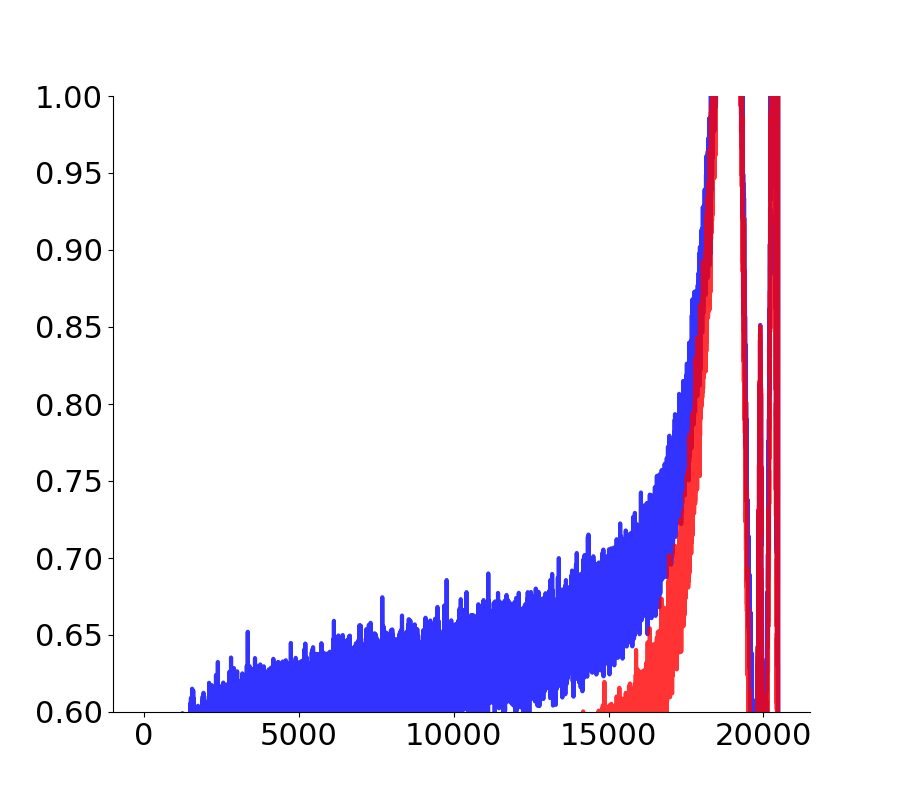

In [55]:
edfa_gdomain=np.load('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/DFAexp_beta_E_812alpha_10min_20khzsim_deci500_125sec_polyorder3.npy')
idfa_gdomain=np.load('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/DFAexp_beta_I_812alpha_10min_20khzsim_deci500_125sec_polyorder3.npy')

plt.figure(figsize=(9,8))
plt.plot(np.arange(1,len(idfa_gdomain)),idfa_gdomain[1:],c='b',lw=3,label='Inh activity',alpha=0.8)
plt.plot(np.arange(1,len(idfa_gdomain)),ndfa[1:],c='k',lw=3,label='Noise',alpha=0.8)
plt.plot(np.arange(1,len(edfa_gdomain)),edfa_gdomain[1:],c='r',lw=3,label='Exc activity',alpha=0.8)

plt.plot(np.arange(1,len(idfa_gdomain)),0.5*np.ones(len(idfa_gdomain)-1),c='k',ls='--',lw=3,label='Noise',alpha=0.8)
#plt.xscale('log')
#plt.xlim((1,10000))
plt.ylim((0.6,1))